<a href="https://colab.research.google.com/github/tomaspettit2506/ML-Assignment/blob/main/ML_Project_G00419414.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Technologies Image Project 2026

* **Name:** Tomás Pettit
* **Student ID:** G00419414

## Introduction
Working with the Garbage Classification dataset in Google Colab requires careful setup to ensure efficient model training and experimentation.

Before running any code cells, it is essential to change the runtime type to **T4 GPU**. Training image‑based machine learning models on a CPU is extremely slow (e.g. ~5 mins per EPOCH) and can significantly delay progress, whereas the T4 GPU (e.g. ~10 seconds per EPOCH) provides the necessary acceleration to handle large datasets and deep learning architectures more effectively.

Using GPU hardware not only speeds up training but also improves the overall workflow, making the development process smoother and more responsive.

## Workflow

1. Data Loading & Understanding
2. Data Preprocessing
3. Train / Validation / Test Split
4. Model Training & Tuning
5. Model Comparison & Selection
6. Final Model Evaluation

Before we get started, make sure you create two new folders `/data` for saving to csv & garbage data and `/images`for saving it of graphs, images and my garbage images, by connecting to Google Colab.

## Connected to Google Colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports
This section initialises the environment, imports required libraries, and sets a fixed random seed to ensure reproducibility.

In [2]:
# NumPy and Pandas
import numpy as np
import pandas as pd

# Image processings
from PIL import Image

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Misc
import time
import os
from datetime import datetime
from pathlib import Path
import zipfile
import shutil

# Preprocessing function for MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# TensorFlow (for deep learning models, and prediction garbage photos)
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.utils import load_img, img_to_array

# Set up parameters for loading the dataset
# Image Size
IMAGE_SIZE = [(64, 64), (128, 128), (224, 224)]

# Batch Size
BATCH_SIZE = 32

# Epoch
EPOCH = [3, 10, 15]

# My RANDOM_SEED (Student ID)
RANDOM_SEED = 419414 # My Student ID (No 'G00')
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'TensorFlow: {tf.__version__}')
gpu_devices = tf.config.list_physical_devices('GPU')
print(f'GPU detected: {bool(gpu_devices)}  {gpu_devices}')

TensorFlow: 2.20.0
GPU detected: True  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1.1 Extract the Zip file and make three directories
If you had your `garbage.zip`, extract the zip on the following path. And after, create `garbage_dataset/`, `images/` and `logs/` dir & before checking if the garbage data has been existed.

And check to be sure if the garbage data has been succeeded using `import os`. Add

In [3]:
# Create folders safely
os.makedirs("garbage_dataset", exist_ok=True) # garbage dataset folder
os.makedirs("images", exist_ok=True)    # for saving model predictions
os.makedirs("logs", exist_ok=True)      # for training logs

# Define the path to the zip file
zip_file_path = '/content/drive/MyDrive/garbage.zip'

# Define the directory to extract the contents to
extract_dir = '/content/garbage_dataset'

# Check if the directory already exists
if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

# Create the extraction directory
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
    if os.path.exists(extract_dir):
        print(f"Successfully extracted '{zip_file_path}' to '{extract_dir}'.")
    else:
        print(f"Extraction failed. Directory '{extract_dir}' already exists.")

Successfully extracted '/content/drive/MyDrive/garbage.zip' to '/content/garbage_dataset'.


### 1.2 Add to the Results and Show Curves to each Keras History

In [4]:
results_df = pd.DataFrame(columns=[
    "Model",
    "Parameters",
    "Train Accuracy",
    "Validation Accuracy",
    "Training Time (s)",
    "Overfitting (Train - Val)",
    "Notes"
])

In [5]:
def show_curves(hist, title=''):
    """Side-by-side accuracy and loss plots from a Keras History object.
    A growing gap between train and val curves indicates overfitting.
    If both curves are low and close together, the model is underfitting."""
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    if title:
        fig.suptitle(title, fontsize=13)

    a1.plot(hist.history['accuracy'],     label='train')
    a1.plot(hist.history['val_accuracy'],  label='val')
    a1.set_xlabel('Epoch'); a1.set_ylabel('Accuracy')
    a1.legend(); a1.grid(True, alpha=0.3)

    a2.plot(hist.history['loss'],     label='train')
    a2.plot(hist.history['val_loss'],  label='val')
    a2.set_xlabel('Epoch'); a2.set_ylabel('Loss')
    a2.legend(); a2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def add_to_results(df, model_name, params, train_acc, val_acc, training_time, notes=""):
    """
    Adds a new row to the results DataFrame and prevents duplicates.

    Args:
        df (pd.DataFrame): The DataFrame to add the new row to.
        model_name (str): The name of the model.
        params (dict): A dictionary containing the model's parameters.
        train_acc (float): The training
        accuracy of the model.
        val_acc (float): The validation accuracy of the model.
        training_time (float): The training time of the model.
        notes (str, optional): Additional notes or comments. Defaults to an empty string.

    Returns:
        pd.DataFrame: The updated DataFrame.
    """

    # Check if the model is already in the dataframe
    if model_name in df["Model"].values:
        print(f"'{model_name}' is already in the results table. Skipping.")
        return df

    # Calculate overfitting
    overfitting = train_acc - val_acc

    # Create a new row as a dictionary
    new_row = {
        "Model": model_name,
        "Parameters": str(params),
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Training Time (s)": training_time,
        "Overfitting (Train - Val)": overfitting,
        "Notes": notes
    }

    # Append the new row
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

    # Save the updated dataframe
    df.to_csv("logs/results.csv", index=False)

    print(f"Added '{model_name}' to the results table.")
    return df

# Load previous results if available
for _results_path in ["logs/results.csv", "cnn_results.csv"]:
    if os.path.exists(_results_path):
        results_df = pd.read_csv(_results_path)
        break

## 2. Data Loading and Understanding - Garbage Dataset

The dataset consists of images of different types of waste materials. Each class is stored in a separate folder.

I will:

-   Load images
-   Convert to feature vectors
-   Create labels
-   Inspect dataset structure

In [6]:
DATA_DIR = Path("garbage_dataset/garbage")

print("Dataset exists:", DATA_DIR.exists())
print("Dataset path:", DATA_DIR.resolve())

Dataset exists: True
Dataset path: /content/garbage_dataset/garbage


In [7]:
# Load the dataset using Keras utility
full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[1],
    batch_size=BATCH_SIZE
)

Found 12259 files belonging to 10 classes.


## 2.1 Class Distribution and Imbalance
The dataset shows nearly 4 times imbalance between the largest class (clothes: 1892) and smallest (trash: 453), which will be monitored using class-wise metrics.

In [8]:
print("Class Distribution\n")

class_names = [d.name for d in DATA_DIR.iterdir() if d.is_dir()]
class_counts = {}

for class_name in class_names:
    class_path = DATA_DIR / class_name
    image_files = [f for f in class_path.iterdir() if f.is_file()]
    class_counts[class_name] = len(image_files)

df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])

# 2 Decimal point
df["Percentage (%)"] = df["Count"].apply(lambda x: round(x / df["Count"].sum() * 100, 2))
df

Class Distribution



,Class,Count,Percentage (%)
0,biological,699,5.70
1,trash,453,3.70
2,battery,756,6.17
3,metal,930,7.59
4,paper,1336,10.90
5,clothes,1892,15.43
6,shoes,1449,11.82
7,cardboard,1411,11.51
8,glass,1736,14.16
9,plastic,1597,13.03


### Figure 1: Bar Chart Garbage Distribution

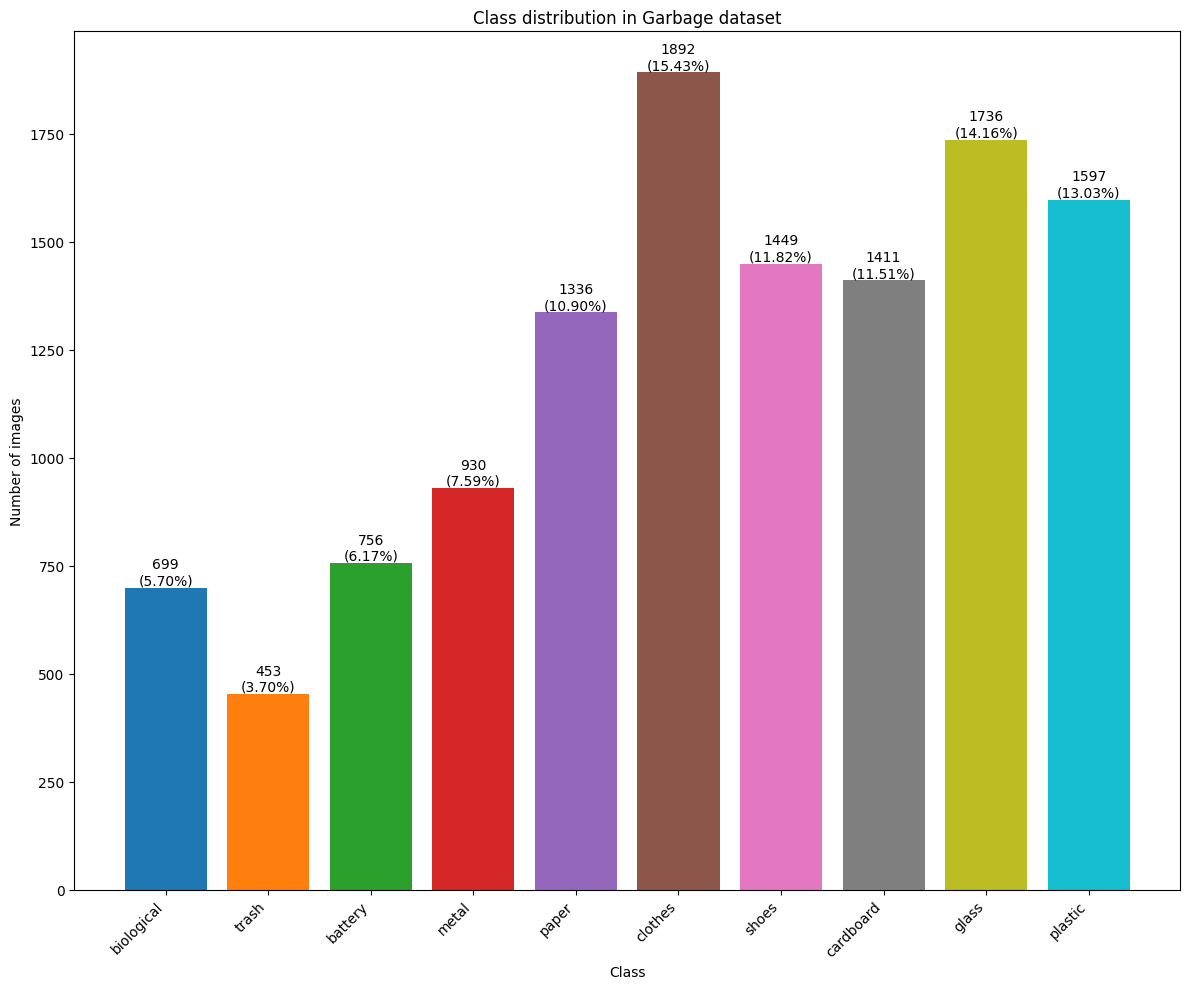

In [9]:
# Color variables (10 bars)
COLOR_BARS = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
]

# Percentage of images out of total images
total_images = sum(class_counts.values())
percentages = {class_name: (count / total_images) * 100 for class_name, count in class_counts.items()}

# Visualize class distribution
plt.figure(figsize=(12, 10))
plt.bar(class_counts.keys(), class_counts.values(), color=COLOR_BARS)

for i, count in enumerate(class_counts.values()):
    plt.text(i, count, f"{count}\n({percentages[class_names[i]]:.2f}%)", ha='center', va='bottom')

plt.xlabel("Class")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Class distribution in Garbage dataset")
plt.tight_layout()
plt.show()

### Figure 2: Sample Images from the dataset & Pixel Range

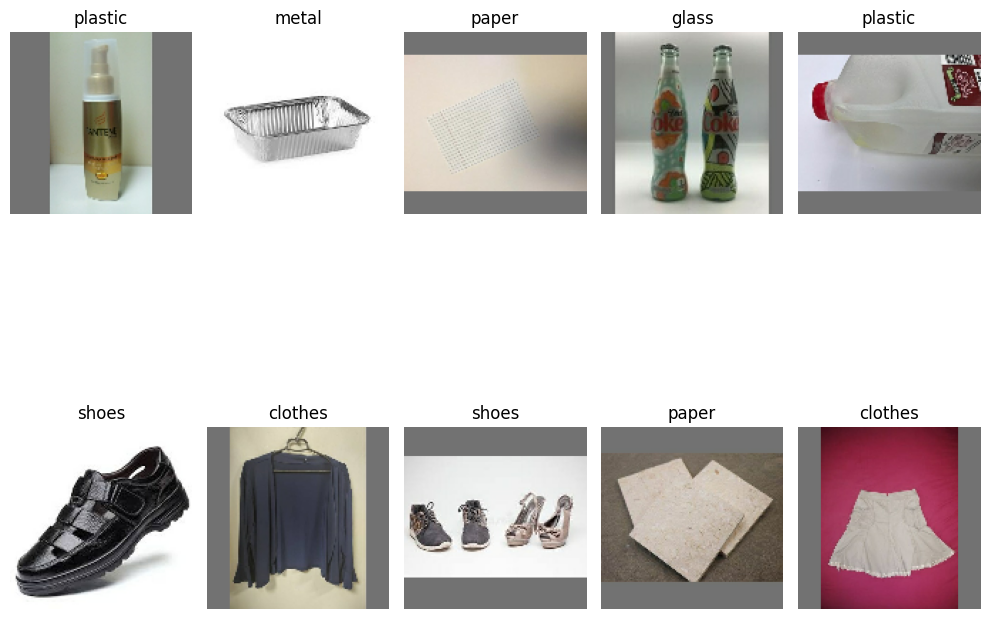

In [10]:
# Sample some images from the dataset
images_batch, labels_batch = next(iter(full_ds))

plt.figure(figsize=(10, 10))

for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images_batch[i].numpy().astype("uint8"))
    plt.title(full_ds.class_names[labels_batch[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

#### 2.1.1 Check pixel value range and dtype

In [11]:
print("Pixel dtype:", images_batch.dtype)
print("Min pixel value:", tf.reduce_min(images_batch).numpy())
print("Max pixel value:", tf.reduce_max(images_batch).numpy())

Pixel dtype: <dtype: 'float32'>
Min pixel value: 0.0
Max pixel value: 255.0


#### 2.1.2 Data Quality

In [12]:
# Checking for corrupted images in the dataset.

bad_files = []

for class_name in class_names:
    class_path = DATA_DIR / class_name
    for file_path in class_path.iterdir():
        try:
            with Image.open(file_path) as img:
                img.verify()  # check if image is valid
        except Exception:
            bad_files.append(file_path)

print("Number of corrupted images:", len(bad_files))

Number of corrupted images: 0


## 3. Train (70%), Validation (10%), and Test Split (20%)
Splitting data into 70% training, 10% validation, and 20% test sets with fixed random seed for reproducibility.

### 3.1 First Split: Train (70%) and Temporary (30%)

In [13]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[1],
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[1],
    batch_size=BATCH_SIZE
)

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


### 3.2 Second Split: split Temporary into Validation (10%) and Test (20%)

In [14]:
temp_size = tf.data.experimental.cardinality(temp_ds).numpy()  # number of batches
val_size = temp_size // 3  # exactly 1/3 of temp

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

### 3.3 Check sizes

In [15]:
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
test_batches = tf.data.experimental.cardinality(test_ds).numpy()

print("Train batches:", train_batches)
print("Validation batches:", val_batches)
print("Test batches:", test_batches)

print("-------------------------------")
print("Approx total samples:")
print("Train:", train_batches * BATCH_SIZE)
print("Validation:", val_batches * BATCH_SIZE)
print("Test:", test_batches * BATCH_SIZE)

Train batches: 269
Validation batches: 38
Test batches: 77
-------------------------------
Approx total samples:
Train: 8608
Validation: 1216
Test: 2464


## 4. Preprocessing
### 4.1 Normalisation layer to scale pixel values to [0, 1]

In [16]:
normalisation_layer = layers.Rescaling(1./255)

### 4.2 Apply normalization to all datasets

In [17]:
train_ds = train_ds.map(lambda x, y: (normalisation_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalisation_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalisation_layer(x), y))

## 5. CNN From Scratch
Building and training custom CNN models to establish a baseline, then experimenting with dropout, data augmentation, architecture variations, and grayscale vs RGB inputs.

### 5.1 Baseline CNN (RGB, 128×128)
Starting with a simple 3-layer CNN to establish a baseline and identify overfitting issues.

In [18]:
model = models.Sequential()

# Step 1: Input layer
model.add(layers.Input(shape=(128, 128, 3)))

# Step 2: Convolutional Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Step 3: Convolutional Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Step 4: Convolutional Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Step 5: Flatten and Dense layers
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))

# Step 6: Output layer
model.add(layers.Dense(len(class_names), activation='softmax'))

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Train the model and measure training time
print("CNN Scratch Training Time")
print("-------------------------")

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCH[1]
)

end_time = time.time()
training_time = end_time - start_time

# Extract final metrics
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f'\nTraining time on Baseline CNN: {training_time} seconds')

CNN Scratch Training Time
-------------------------
Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.4074 - loss: 1.6812 - val_accuracy: 0.5354 - val_loss: 1.3842
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.5762 - loss: 1.2222 - val_accuracy: 0.5839 - val_loss: 1.2918
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.6751 - loss: 0.9597 - val_accuracy: 0.5921 - val_loss: 1.3104
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.7487 - loss: 0.7431 - val_accuracy: 0.6143 - val_loss: 1.3600
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.8117 - loss: 0.5471 - val_accuracy: 0.6143 - val_loss: 1.5513
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.8688 - loss: 0.3953 - val_accuracy: 0.6151 - val_loss: 1.6178
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.8948 - loss: 0.3171 - val_accuracy: 0.6340 - val_loss: 1.8257
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 

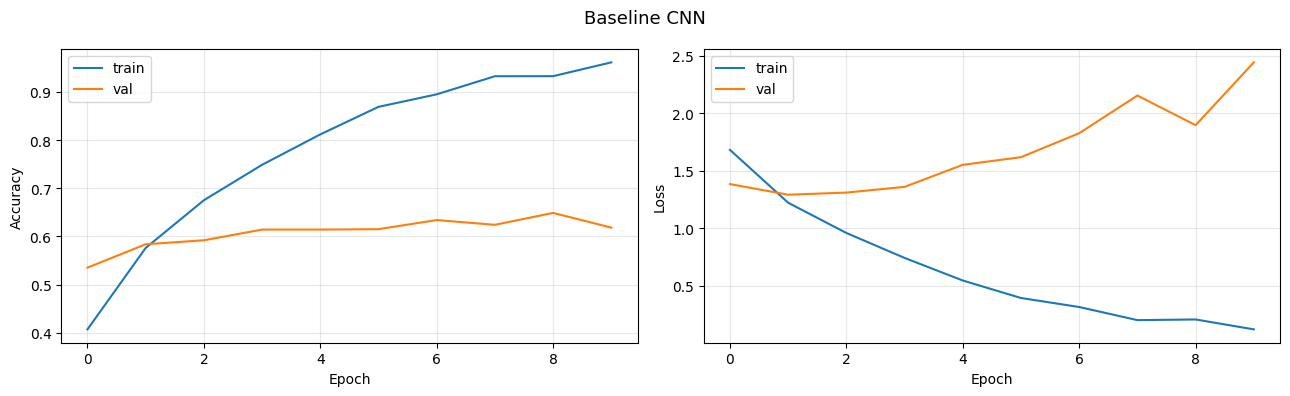

In [21]:
show_curves(history, title="Baseline CNN")

In [22]:
# Evaluation
print("Evaluate Baseline CNN")
print("---------------------")

train_loss, train_acc = model.evaluate(train_ds)
val_loss, val_acc = model.evaluate(val_ds)

Evaluate Baseline CNN
---------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9536 - loss: 0.1412
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6250 - loss: 2.3798


In [23]:
# Add to results dataframe
results_df = add_to_results(
    df=results_df,
    model_name="Baseline CNN",
    params={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "epochs": EPOCH[1]
    },
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Initial baseline CNN trained on RGB images"
)

results_df

Added 'Baseline CNN' to the results table.


/tmp/ipykernel_964/1636728472.py:60: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


,Model,Parameters,Train Accuracy,Validation Accuracy,Training Time (s),Overfitting (Train - Val),Notes
0,Baseline CNN,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.953624,0.625,110.302091,0.328624,Initial baseline CNN trained on RGB images


The baseline CNN achieved ~89.9% training accuracy but only ~62.5% validation accuracy, clearly indicating overfitting that needs to be addressed with regularization techniques.

### 5.2 CNN with Dropout
Adding 0.2 dropout regularization to reduce overfitting and improve validation accuracy.

In [24]:
model_dropout2 = models.Sequential()

# Step 1: Input - same as before to ensure fair comparison
model_dropout2.add(layers.Input(shape=(128, 128, 3)))

# Step 2: Conv blocks
model_dropout2.add(layers.Conv2D(32, (3,3), activation='relu'))
model_dropout2.add(layers.MaxPooling2D((2,2)))

model_dropout2.add(layers.Conv2D(64, (3,3), activation='relu'))
model_dropout2.add(layers.MaxPooling2D((2,2)))

model_dropout2.add(layers.Conv2D(128, (3,3), activation='relu'))
model_dropout2.add(layers.MaxPooling2D((2,2)))

# Step 3: Dense
model_dropout2.add(layers.Flatten())
model_dropout2.add(layers.Dense(128, activation='relu'))

# Step 4: Dropout added
model_dropout2.add(layers.Dropout(0.2))

# Step 5: Output
model_dropout2.add(layers.Dense(len(class_names), activation='softmax'))

In [25]:
# Compile
model_dropout2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_dropout2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
print("Improved CNN Training Time")
print("--------------------------")

# Train
start_time = time.time()

history_dropout = model_dropout2.fit(
    train_ds,
    validation_data=val_ds,
    epochs= EPOCH[1]
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on Improved CNN: {training_time} seconds')

Improved CNN Training Time
--------------------------
Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.3825 - loss: 1.7517 - val_accuracy: 0.5181 - val_loss: 1.4476
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.5543 - loss: 1.3082 - val_accuracy: 0.5863 - val_loss: 1.2615
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.6375 - loss: 1.0612 - val_accuracy: 0.6324 - val_loss: 1.1345
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.6961 - loss: 0.8894 - val_accuracy: 0.6324 - val_loss: 1.1642
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.7544 - loss: 0.7028 - val_accuracy: 0.6439 - val_loss: 1.2053
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.8049 - loss: 0.5741 - val_accuracy: 0.6160 - val_loss: 1.3427
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.8457 - loss: 0.4393 - val_accuracy: 0.6521 - val_loss: 1.3735
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━

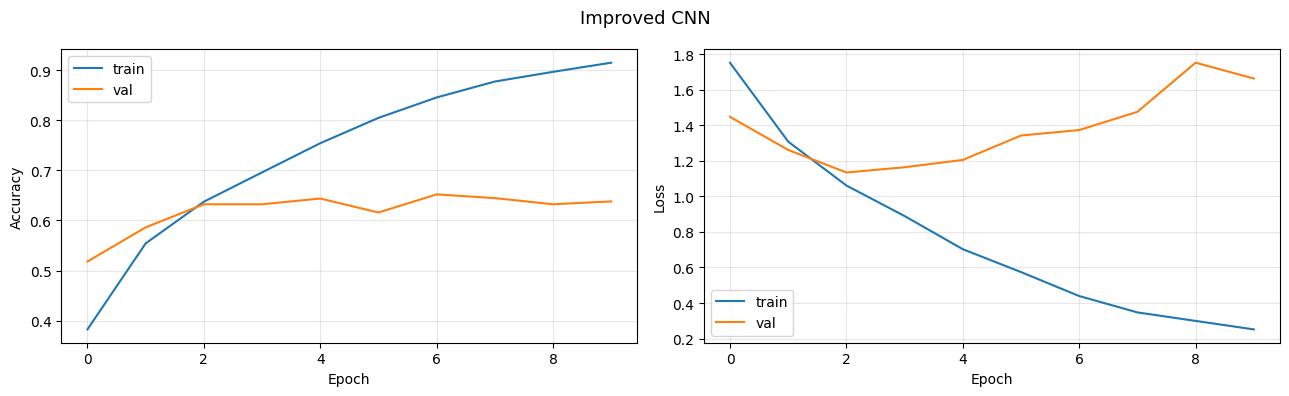

In [27]:
show_curves(history_dropout, title="Improved CNN")

In [28]:
# Evaluate
print("Evaluate Improved CNN")
print("----------------------")

# Accuracy
train_loss, train_acc = model_dropout2.evaluate(train_ds)
val_loss, val_acc = model_dropout2.evaluate(val_ds)

Evaluate Improved CNN
----------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9635 - loss: 0.1240
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6447 - loss: 1.6233


In [29]:
# Results table
results_df = add_to_results(
    df=results_df,
    model_name="CNN + Dropout (0.2)",
    params={"epochs": EPOCH[1], "dropout": 0.2},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Dropout added"
)

Added 'CNN + Dropout (0.2)' to the results table.


Dropout improved validation accuracy to ~66.3% (from ~62.5%), showing modest gains in generalization at the cost of slightly lower training accuracy.

### 5.3 CNN with Reduced Image Size (64 x 64)

In [30]:
# New Split: Train (70%) and Temporary (30%)
# Use `IMAGE_SIZE_64` (64, 64)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[0],
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[0],
    batch_size=BATCH_SIZE
)

# Second Split: split Temporary into Validation (10%) and Test (20%)
temp_size = tf.data.experimental.cardinality(temp_ds).numpy()
val_size = temp_size // 3

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

# Normalisation layer to scale pixel values to [0, 1]
normalisation_layer = layers.Rescaling(1./255)

# Apply normalization to all datasets
train_ds = train_ds.map(lambda x, y: (normalisation_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalisation_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalisation_layer(x), y))

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [31]:
model_img64 = models.Sequential()

# Step 1: Input layer
model_img64.add(layers.Input(shape=(64, 64, 3)))

# Step 2: Convolutional Block 1
model_img64.add(layers.Conv2D(32, (3,3), activation='relu'))
model_img64.add(layers.MaxPooling2D((2,2)))

# Step 3: Convolutional Block 2
model_img64.add(layers.Conv2D(64, (3,3), activation='relu'))
model_img64.add(layers.MaxPooling2D((2,2)))

# Step 4: Convolutional Block 3
model_img64.add(layers.Conv2D(128, (3,3), activation='relu'))
model_img64.add(layers.MaxPooling2D((2,2)))

# Step 5: Flatten and Dense layers
model_img64.add(layers.Flatten())
model_img64.add(layers.Dense(128, activation='relu'))

# Step 6: Output layer
model_img64.add(layers.Dense(len(class_names), activation='softmax'))

In [32]:
# Compile
model_img64.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_img64.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
print("CNN + Image Resize Training Time")
print("--------------------------------")

# Train the model and measure training time
start_time = time.time()

historyimg64 = model_img64.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCH[1]
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on CNN + Image Resize: {training_time} seconds')

CNN + Image Resize Training Time
--------------------------------
Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.3575 - loss: 1.7941 - val_accuracy: 0.5066 - val_loss: 1.4542
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.5331 - loss: 1.3443 - val_accuracy: 0.5337 - val_loss: 1.3818
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6109 - loss: 1.1388 - val_accuracy: 0.5979 - val_loss: 1.2080
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.6706 - loss: 0.9790 - val_accuracy: 0.6094 - val_loss: 1.1849
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.7128 - loss: 0.8493 - val_accuracy: 0.6127 - val_loss: 1.1830
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7512 - loss: 0.7344 - val_accuracy: 0.6250 - val_loss: 1.1654
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.7921 - loss: 0.6140 - val_accuracy: 0.6332 - val_loss: 1.1973
Epoch 8/10
269/269 ━━━━━━━━━━

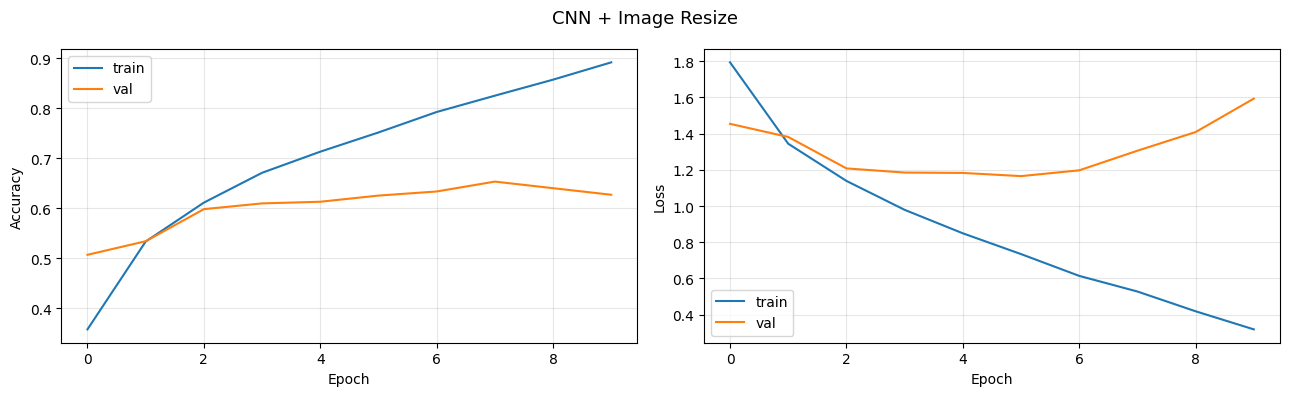

In [34]:
show_curves(historyimg64, title="CNN + Image Resize")

In [35]:
# Evaluation
print("Evaluate CNN + Image Resize")
print("---------------------------")

train_loss, train_acc = model_img64.evaluate(train_ds)
val_loss, val_acc = model_img64.evaluate(val_ds)

Evaluate CNN + Image Resize
---------------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8915 - loss: 0.3119
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6258 - loss: 1.5883


In [36]:
# Add to results dataframe
results_df = add_to_results(
    df=results_df,
    model_name="Baseline CNN (64x64)",
    params={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "epochs": EPOCH[1]
    },
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Baseline CNN retrained on 64x64 images"
)

results_df

Added 'Baseline CNN (64x64)' to the results table.


,Model,Parameters,Train Accuracy,Validation Accuracy,Training Time (s),Overfitting (Train - Val),Notes
0,Baseline CNN,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.953624,0.625000,110.302091,0.328624,Initial baseline CNN trained on RGB images
1,CNN + Dropout (0.2),"{'epochs': 10, 'dropout': 0.2}",0.963528,0.644737,118.576987,0.318792,Dropout added
2,Baseline CNN (64x64),"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.891517,0.625822,96.351429,0.265695,Baseline CNN retrained on 64x64 images


### 5.4 CNN with Data Augmentation (Aggressive — "Bad")
To explore the limits of augmentation, a more aggressive pipeline was applied to the original **128×128** dataset: horizontal + vertical flipping, 0.3 rotation, 0.2 zoom, brightness, and contrast jitter. The 128×128 datasets are reloaded fresh in the cell below before training.

In [37]:
train_ds_128 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[1],  # IMAGE_SIZE[1] = (128, 128)
    batch_size=BATCH_SIZE
)

temp_ds_128 = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[1],
    batch_size=BATCH_SIZE
)

temp_size_128 = tf.data.experimental.cardinality(temp_ds_128).numpy()
val_size_128  = temp_size_128 // 3

val_ds_128  = temp_ds_128.take(val_size_128)
test_ds_128 = temp_ds_128.skip(val_size_128)

# Normalise
normalisation_layer = layers.Rescaling(1./255)
train_ds_128 = train_ds_128.map(lambda x, y: (normalisation_layer(x), y))
val_ds_128   = val_ds_128.map(lambda x, y:  (normalisation_layer(x), y))
test_ds_128  = test_ds_128.map(lambda x, y: (normalisation_layer(x), y))

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [38]:
model_aug_bad = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Worst augmentation layers (inline - not reused from another model)
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),

    # Conv blocks (same architecture as baseline)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Dense
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(len(class_names), activation='softmax')
])


In [39]:
model_aug_bad.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_aug_bad.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 128, 128, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
print("Worst Augmentation Training Time (128x128)")
print("------------------------------------------------")

start_time = time.time()

# NOTE: uses the original 128x128 train_ds (loaded before section 5.3)
history_aug_bad = model_aug_bad.fit(
    train_ds_128,
    validation_data=val_ds_128,
    epochs=EPOCH[1]  # EPOCH[1] = 10
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on Worst Augmentation: {training_time} seconds')

Worst Augmentation Training Time (128x128)
------------------------------------------------
Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.1396 - loss: 2.4450 - val_accuracy: 0.1645 - val_loss: 2.2500
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.1466 - loss: 2.2349 - val_accuracy: 0.1637 - val_loss: 2.2221
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.1485 - loss: 2.2300 - val_accuracy: 0.1604 - val_loss: 2.2181
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.1500 - loss: 2.2304 - val_accuracy: 0.1538 - val_loss: 2.2154
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.1483 - loss: 2.2301 - val_accuracy: 0.1497 - val_loss: 2.2176
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.1497 - loss: 2.2319 - val_accuracy: 0.1604 - val_loss: 2.2096
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.1500 - loss: 2.2858 - val_accuracy: 0.1694 - val_loss: 2.2154

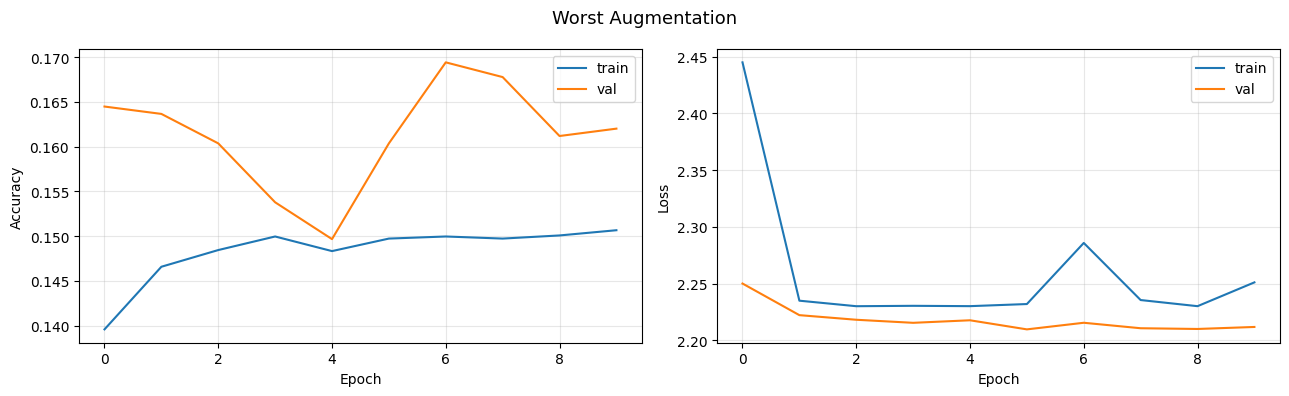

In [41]:
show_curves(history_aug_bad, title="Worst Augmentation")

In [42]:
print("Evaluate Worst Augmentation")
print("---------------------------------")

train_loss, train_acc = model_aug_bad.evaluate(train_ds_128)
val_loss, val_acc = model_aug_bad.evaluate(val_ds_128)

Evaluate Worst Augmentation
---------------------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.1503 - loss: 2.2276
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1612 - loss: 2.2136


In [43]:
results_df = add_to_results(
    df=results_df,
    model_name="CNN + Augmentation (WORST)",
    params={"epochs": EPOCH[1], "augmentation": True},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Very worst augmentation on 128x128 images"
)

Added 'CNN + Augmentation (WORST)' to the results table.


Over the worst augmentation (horizontal + vertical flips, 0.3 rotation, zoom, brightness, and contrast) severely harmed performance — training accuracy dropped to **~57.7%** and validation to **~52.6%**. The model could not learn meaningful features when images were too distorted, confirming that augmentation must be kept mild and purposeful.

### 5.5 CNN with Data Augmentation (Best)
Building on the 64×64 setup from section 5.3, mild augmentation (horizontal flip + 0.05 rotation) is applied during training only. This strategy improves generalisation without distorting class-distinguishing features.

In [44]:
# Data augmentation pipeline (for training dataset only)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    #layers.RandomZoom(0.1)
])

In [45]:
# Build a new model with augmentation layer included
model_aug = models.Sequential()

# Step 1: Input
model_aug.add(layers.Input(shape=(64, 64, 3)))

# Step 2: Augmentation
model_aug.add(data_augmentation)

# Step 3: Conv blocks
model_aug.add(layers.Conv2D(32, (3,3), activation='relu'))
model_aug.add(layers.MaxPooling2D((2,2)))

model_aug.add(layers.Conv2D(64, (3,3), activation='relu'))
model_aug.add(layers.MaxPooling2D((2,2)))

model_aug.add(layers.Conv2D(128, (3,3), activation='relu'))
model_aug.add(layers.MaxPooling2D((2,2)))

# Step 4: Dense
model_aug.add(layers.Flatten())
model_aug.add(layers.Dense(128, activation='relu'))

# Step 5: Output
model_aug.add(layers.Dense(len(class_names), activation='softmax'))

In [46]:
# Compile
model_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_aug.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
print("Best Augmentation Training Time")
print("-------------------------------")

# Train the model and measure training time
start_time = time.time()

history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCH[2] # EPOCH[2] = 15
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on Best Augmentation: {training_time} seconds')

Best Augmentation Training Time
-------------------------------
Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.3393 - loss: 1.8623 - val_accuracy: 0.4531 - val_loss: 1.6026
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.5014 - loss: 1.4329 - val_accuracy: 0.5271 - val_loss: 1.3724
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.5602 - loss: 1.2719 - val_accuracy: 0.5099 - val_loss: 1.4437
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.5981 - loss: 1.1857 - val_accuracy: 0.6143 - val_loss: 1.1754
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6354 - loss: 1.0868 - val_accuracy: 0.6160 - val_loss: 1.1700
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.6483 - loss: 1.0202 - val_accuracy: 0.6365 - val_loss: 1.0803
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.6799 - loss: 0.9453 - val_accuracy: 0.6447 - val_loss: 1.0812
Epoch 8/15
269/269 ━━━━━━━━

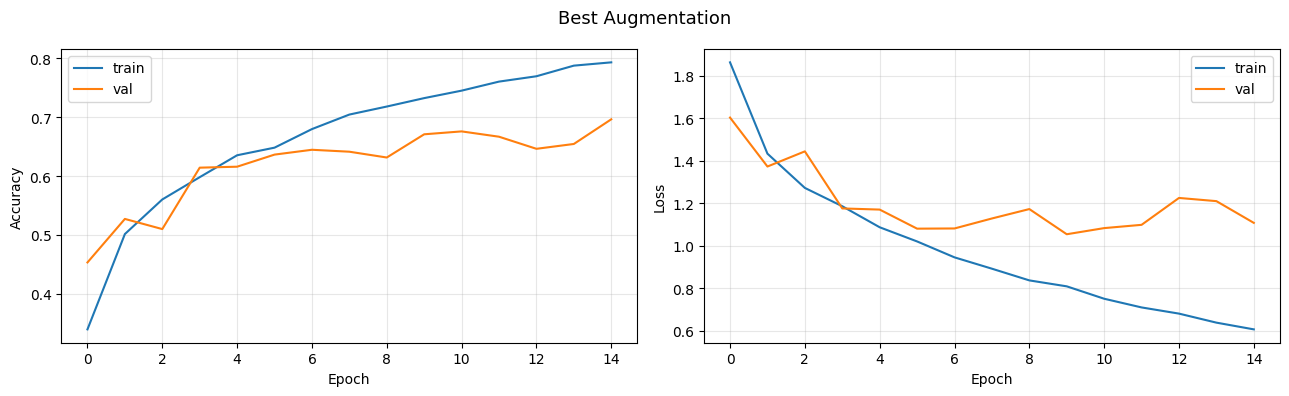

In [48]:
show_curves(history_aug, title="Best Augmentation")

In [49]:
print("Evaluate Best Augmentation")
print("--------------------------")

train_loss, train_acc = model_aug.evaluate(train_ds)
val_loss, val_acc = model_aug.evaluate(val_ds)

Evaluate Best Augmentation
--------------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8187 - loss: 0.5288
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7023 - loss: 1.0782


In [50]:
results_df = add_to_results(
    df=results_df,
    model_name="CNN + Augmentation (BEST)",
    params={"epochs": EPOCH[2], "augmentation": True},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Best model: 64x64, flip + 0.05 rotation"
)

results_df

Added 'CNN + Augmentation (BEST)' to the results table.


,Model,Parameters,Train Accuracy,Validation Accuracy,Training Time (s),Overfitting (Train - Val),Notes
0,Baseline CNN,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.953624,0.625000,110.302091,0.328624,Initial baseline CNN trained on RGB images
1,CNN + Dropout (0.2),"{'epochs': 10, 'dropout': 0.2}",0.963528,0.644737,118.576987,0.318792,Dropout added
2,Baseline CNN (64x64),"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.891517,0.625822,96.351429,0.265695,Baseline CNN retrained on 64x64 images
3,CNN + Augmentation (WORST),"{'epochs': 10, 'augmentation': True}",0.150315,0.161184,132.929084,-0.010870,Very worst augmentation on 128x128 images
4,CNN + Augmentation (BEST),"{'epochs': 15, 'augmentation': True}",0.818690,0.702303,154.984414,0.116388,"Best model: 64x64, flip + 0.05 rotation"


Mild augmentation on 64×64 images achieved the best custom-CNN validation accuracy so far at **70.3%**, reducing the train–val gap to 0.15 compared to 0.32 for the baseline. This configuration is used as the base for the deeper architecture experiments below.

### 5.6 Deeper Architecture (Extra Conv Layer)
Adding a fourth convolutional block (256 filters) on top of the best-performing augmented 64×64 model to test whether increased depth improves feature extraction.

In [51]:
# Build a new deeper model (extra Conv layer)
model_deeper = models.Sequential()

# Input
model_deeper.add(layers.Input(shape=(64, 64, 3)))

# Augmentation FIRST
model_deeper.add(data_augmentation)

# Conv blocks
model_deeper.add(layers.Conv2D(32, (3,3), activation='relu'))
model_deeper.add(layers.MaxPooling2D((2,2)))

model_deeper.add(layers.Conv2D(64, (3,3), activation='relu'))
model_deeper.add(layers.MaxPooling2D((2,2)))

model_deeper.add(layers.Conv2D(128, (3,3), activation='relu'))
model_deeper.add(layers.MaxPooling2D((2,2)))

# NEW BLOCK
model_deeper.add(layers.Conv2D(256, (3,3), activation='relu'))
model_deeper.add(layers.MaxPooling2D((2,2)))

# Dense
model_deeper.add(layers.Flatten())
model_deeper.add(layers.Dense(128, activation='relu'))

# Output
model_deeper.add(layers.Dense(len(class_names), activation='softmax'))

In [52]:
model_deeper.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_deeper.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,906 (1.99 MB)

 Trainable params: 520,906 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
print("Deeper Architecture Training Time")
print("---------------------------------")

# Train the model and measure time
start_time = time.time()

history_deeper = model_deeper.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCH[2] # EPOCH[2] = 15
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on Deeper Architecture: {training_time} seconds')

Deeper Architecture Training Time
---------------------------------
Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.2880 - loss: 1.9747 - val_accuracy: 0.4219 - val_loss: 1.6740
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.4683 - loss: 1.5274 - val_accuracy: 0.4762 - val_loss: 1.5247
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.5333 - loss: 1.3464 - val_accuracy: 0.5296 - val_loss: 1.3780
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.5820 - loss: 1.2214 - val_accuracy: 0.5938 - val_loss: 1.1819
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.6087 - loss: 1.1470 - val_accuracy: 0.5822 - val_loss: 1.3016
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.6383 - loss: 1.0687 - val_accuracy: 0.5724 - val_loss: 1.2610
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.6512 - loss: 1.0195 - val_accuracy: 0.6530 - val_loss: 1.0780
Epoch 8/15
269/269 ━━━━━

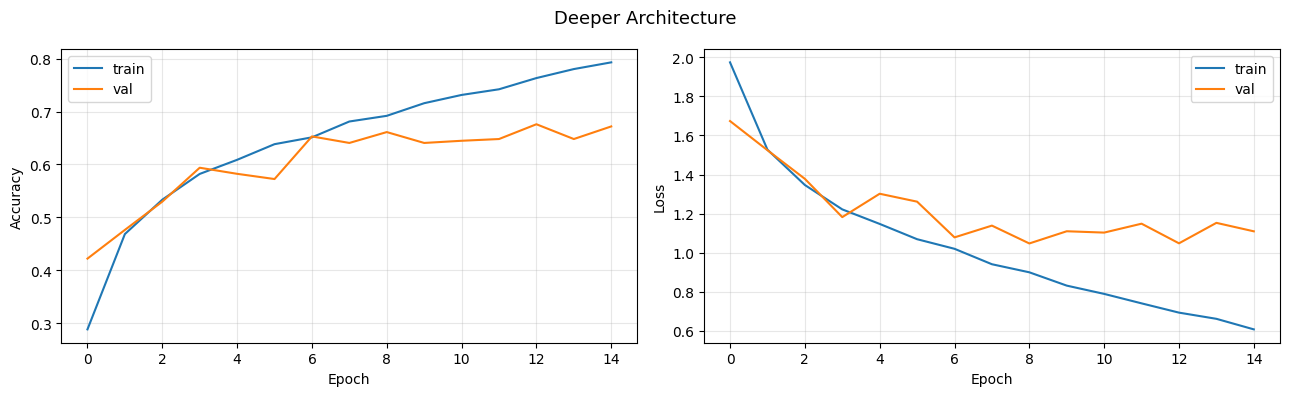

In [54]:
show_curves(history_deeper, title="Deeper Architecture")

In [55]:
print("Evaluate Deeper Architecture")
print("----------------------------")

train_loss, train_acc = model_deeper.evaluate(train_ds)
val_loss, val_acc = model_deeper.evaluate(val_ds)

Evaluate Deeper Architecture
----------------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.8157 - loss: 0.5346
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6793 - loss: 1.0853


In [56]:
results_df = add_to_results(
    df=results_df,
    model_name="CNN + Deeper Architecture (Extra Conv Layer)",
    params={"epochs": EPOCH[2], "extra_conv": True},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Extra Conv layer added"
)

Added 'CNN + Deeper Architecture (Extra Conv Layer)' to the results table.


The deeper 256-filter model did not improve validation accuracy, suggesting the added capacity overfits the relatively small dataset. A smaller extra layer (128 filters) is tested next.

#### 5.6.1 Smaller Extra Conv Layer
Testing a 128-filter extra convolutional block as a lighter alternative to the 256-filter variant.

In [57]:
# Build a new deeper-but-smaller model
model_deeper_small = models.Sequential()

# Input
model_deeper_small.add(layers.Input(shape=(64, 64, 3)))

# Augmentation FIRST
model_deeper_small.add(data_augmentation)

# Conv blocks
model_deeper_small.add(layers.Conv2D(32, (3,3), activation='relu'))
model_deeper_small.add(layers.MaxPooling2D((2,2)))

model_deeper_small.add(layers.Conv2D(64, (3,3), activation='relu'))
model_deeper_small.add(layers.MaxPooling2D((2,2)))

model_deeper_small.add(layers.Conv2D(128, (3,3), activation='relu'))
model_deeper_small.add(layers.MaxPooling2D((2,2)))

# Smaller extra layer
model_deeper_small.add(layers.Conv2D(128, (3,3), activation='relu'))
model_deeper_small.add(layers.MaxPooling2D((2,2)))

# Dense
model_deeper_small.add(layers.Flatten())
model_deeper_small.add(layers.Dense(128, activation='relu'))

# Output
model_deeper_small.add(layers.Dense(len(class_names), activation='softmax'))

In [58]:
model_deeper_small.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_deeper_small.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,786 (1.17 MB)

 Trainable params: 307,786 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
print("Deeper Architecture (less filters) Training Time")
print("------------------------------------------------")

start_time = time.time()

history_deeper_small = model_deeper_small.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCH[2] # EPOCH[2] = 15
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on Deeper Architecture (less filters): {training_time} seconds')

Deeper Architecture (less filters) Training Time
------------------------------------------------
Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.2870 - loss: 1.9603 - val_accuracy: 0.4482 - val_loss: 1.6706
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.4598 - loss: 1.5370 - val_accuracy: 0.4910 - val_loss: 1.4459
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.5254 - loss: 1.3639 - val_accuracy: 0.5041 - val_loss: 1.4635
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.5576 - loss: 1.2687 - val_accuracy: 0.5600 - val_loss: 1.2719
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.5939 - loss: 1.1884 - val_accuracy: 0.5979 - val_loss: 1.1941
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.6187 - loss: 1.1115 - val_accuracy: 0.5798 - val_loss: 1.2225
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.6362 - loss: 1.0601 - val_accuracy: 0.6406 - val_loss: 1.

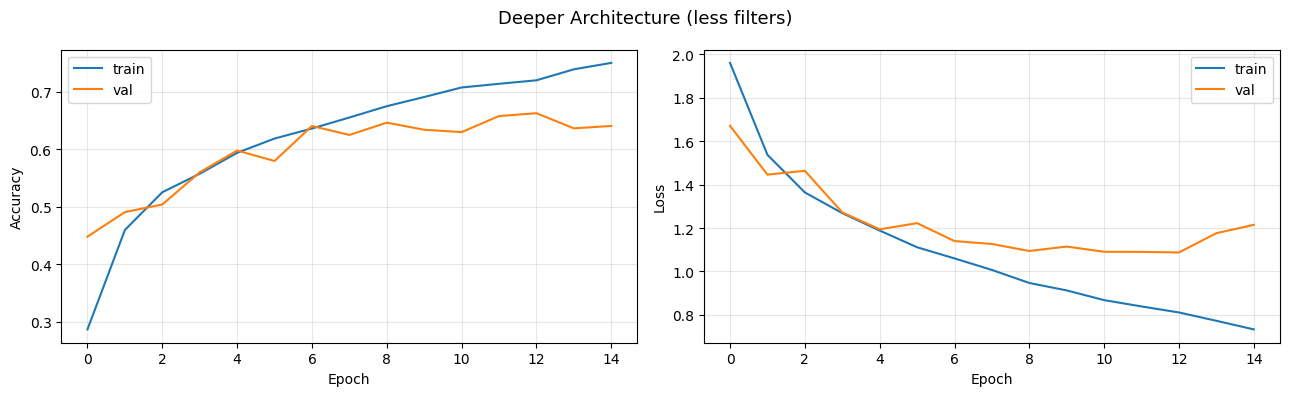

In [60]:
show_curves(history_deeper_small, title="Deeper Architecture (less filters)")

In [61]:
print("Evaluate Deeper Architecture (less filters)")
print("------------------------")

train_loss, train_acc = model_deeper_small.evaluate(train_ds)
val_loss, val_acc = model_deeper_small.evaluate(val_ds)

Evaluate Deeper Architecture (less filters)
------------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.7355 - loss: 0.7730
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6406 - loss: 1.2239


In [62]:
results_df = add_to_results(
    df=results_df,
    model_name="CNN + Smaller Extra Conv Layer",
    params={"epochs": EPOCH[2], "extra_conv": True, "extra_filters": 128},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Smaller extra Conv layer added"
)

Added 'CNN + Smaller Extra Conv Layer' to the results table.


Both deeper architectures (256-filter and 128-filter extra layers) failed to improve on the base augmented 64×64 model. The original 3-layer design with mild augmentation remains the best custom CNN, confirming that adding depth is not always beneficial — especially when the dataset is limited. The best validation accuracy for custom CNNs is locked at **70.3%** (CNN + Augmentation, best).

### 5.7 Grayscale vs RGB Comparison

In [63]:
# Load grayscale datasets for comparison
train_ds_gray = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[0], # IMAGE_SIZE=(64, 64)
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

temp_ds_gray = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[0],
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

temp_size = tf.data.experimental.cardinality(temp_ds_gray).numpy()
val_size = temp_size // 3

val_ds_gray = temp_ds_gray.take(val_size)
test_ds_gray = temp_ds_gray.skip(val_size)

normalisation_layer = layers.Rescaling(1./255)

train_ds_gray = train_ds_gray.map(lambda x, y: (normalisation_layer(x), y))
val_ds_gray = val_ds_gray.map(lambda x, y: (normalisation_layer(x), y))

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [64]:
model_gray = models.Sequential()

# Input
model_gray.add(layers.Input(shape=(64, 64, 1)))

# Augmentation (still works!)
model_gray.add(data_augmentation)

# SAME architecture as best RGB model
model_gray.add(layers.Conv2D(32, (3,3), activation='relu'))
model_gray.add(layers.MaxPooling2D((2,2)))

model_gray.add(layers.Conv2D(64, (3,3), activation='relu'))
model_gray.add(layers.MaxPooling2D((2,2)))

model_gray.add(layers.Conv2D(128, (3,3), activation='relu'))
model_gray.add(layers.MaxPooling2D((2,2)))

model_gray.add(layers.Flatten())
model_gray.add(layers.Dense(128, activation='relu'))

model_gray.add(layers.Dense(len(class_names), activation='softmax'))

In [65]:
model_gray.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_gray.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,914 (2.61 MB)

 Trainable params: 683,914 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
print("Grayscale Model Training Time")
print("-----------------------------")

start_time = time.time()

history_gray = model_gray.fit(
    train_ds_gray,
    validation_data=val_ds_gray,
    epochs=EPOCH[2] # EPOCH[2] = 15
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on Grayscale: {training_time} seconds')

Grayscale Model Training Time
-----------------------------
Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.3129 - loss: 1.9049 - val_accuracy: 0.4523 - val_loss: 1.6369
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.4554 - loss: 1.5503 - val_accuracy: 0.4737 - val_loss: 1.5318
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5117 - loss: 1.4053 - val_accuracy: 0.5263 - val_loss: 1.4112
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5375 - loss: 1.3308 - val_accuracy: 0.5444 - val_loss: 1.3742
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5697 - loss: 1.2446 - val_accuracy: 0.5247 - val_loss: 1.4309
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5918 - loss: 1.1851 - val_accuracy: 0.5641 - val_loss: 1.3568
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6184 - loss: 1.1223 - val_accuracy: 0.6160 - val_loss: 1.1980
Epoch 8/15
269/269 ━━━━━━━━━━━━━━━━━

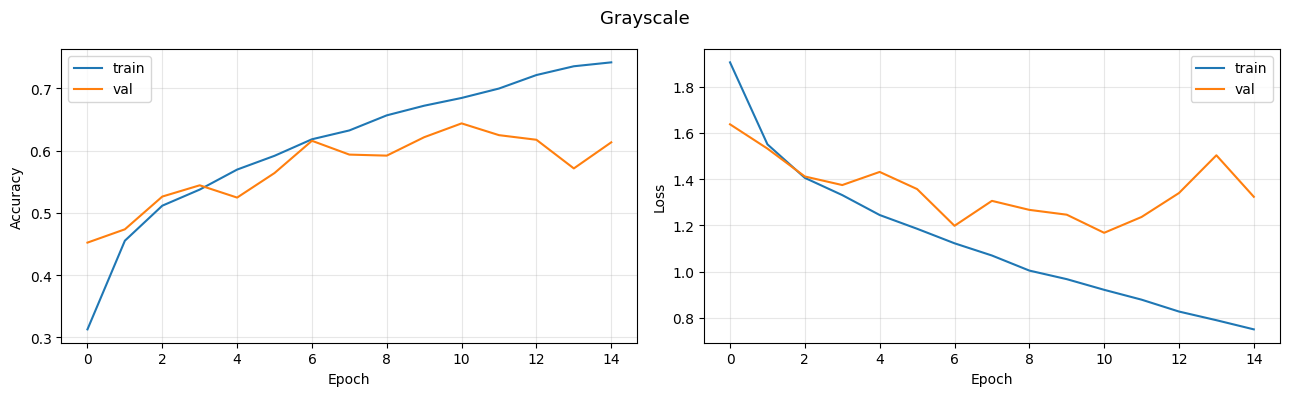

In [67]:
show_curves(history_gray, title="Grayscale")

In [68]:
print("Evaluate Grayscale")
print("------------------")

train_loss, train_acc = model_gray.evaluate(train_ds_gray)
val_loss, val_acc = model_gray.evaluate(val_ds_gray)

Evaluate Grayscale
------------------
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7389 - loss: 0.7745
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6168 - loss: 1.3162


In [69]:
results_df = add_to_results(
    df=results_df,
    model_name="CNN - Grayscale (64x64 + Augmentation)",
    params={"epochs": EPOCH[2], "grayscale": True},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Grayscale comparison"
)

results_df

Added 'CNN - Grayscale (64x64 + Augmentation)' to the results table.


,Model,Parameters,Train Accuracy,Validation Accuracy,Training Time (s),Overfitting (Train - Val),Notes
0,Baseline CNN,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.953624,0.625000,110.302091,0.328624,Initial baseline CNN trained on RGB images
1,CNN + Dropout (0.2),"{'epochs': 10, 'dropout': 0.2}",0.963528,0.644737,118.576987,0.318792,Dropout added
2,Baseline CNN (64x64),"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.891517,0.625822,96.351429,0.265695,Baseline CNN retrained on 64x64 images
3,CNN + Augmentation (WORST),"{'epochs': 10, 'augmentation': True}",0.150315,0.161184,132.929084,-0.010870,Very worst augmentation on 128x128 images
4,CNN + Augmentation (BEST),"{'epochs': 15, 'augmentation': True}",0.818690,0.702303,154.984414,0.116388,"Best model: 64x64, flip + 0.05 rotation"
5,CNN + Deeper Architecture (Extra Conv Layer),"{'epochs': 15, 'extra_conv': True}",0.815661,0.679276,148.090235,0.136384,Extra Conv layer added
6,CNN + Smaller Extra Conv Layer,"{'epochs': 15, 'extra_conv': True, 'extra_filt...",0.735493,0.640625,157.201159,0.094868,Smaller extra Conv layer added
7,CNN - Grayscale (64x64 + Augmentation),"{'epochs': 15, 'grayscale': True}",0.738872,0.616776,121.658829,0.122096,Grayscale comparison


Grayscale images resulted in **59.5%** validation accuracy vs **70.3%** for RGB, confirming that colour information is critical for distinguishing waste categories (e.g. green glass vs clear plastic, orange peel vs cardboard).

## 6. Transfer Learning – MobileNetV2
Leveraging ImageNet pre-trained weights to significantly boost accuracy. Three runs are compared: an initial fine-tuning attempt (Model 8), a frozen-base RERUN to establish a clean baseline (Model 9), and a fine-tuning RERUN on top of the frozen model (Model 10).

### Transfer Learning - Data Preparation

In [70]:
train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[2], # IMAGE_SIZE[2] = (224, 224)
    batch_size=BATCH_SIZE
)

temp_ds_tl = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_SEED,
    image_size=IMAGE_SIZE[2],
    batch_size=BATCH_SIZE
)

# Split temp: validation + test
temp_size = tf.data.experimental.cardinality(temp_ds_tl).numpy()
val_size = temp_size // 3

val_ds_tl = temp_ds_tl.take(val_size)
test_ds_tl = temp_ds_tl.skip(val_size)

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [71]:
# Prefetch datasets for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds_tl = train_ds_tl.prefetch(buffer_size=AUTOTUNE)
val_ds_tl   = val_ds_tl.prefetch(buffer_size=AUTOTUNE)
test_ds_tl  = test_ds_tl.prefetch(buffer_size=AUTOTUNE)

### 6.1 MobileNetV2 Fine-tuned (Initial Attempt)
First attempt at transfer learning: the top 30 layers of MobileNetV2 are unfrozen and trained immediately with a low learning rate (1e-5) for 10 epochs, without first establishing a frozen baseline.

In [72]:
# Load base model with top 30 layers unfrozen (initial fine-tune attempt)
base_model_init = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all except top 30
base_model_init.trainable = True
for layer in base_model_init.layers[:-30]:
    layer.trainable = False

model_tl_init = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Lambda(preprocess_input),
    base_model_init,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model_tl_init.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 1,691,658 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [73]:
model_tl_init.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [74]:
print("Transfer Learning Training Time using MobileNetV2 (Fine-Tuned - Initial)")
print("---------------------------------------------------------------------------")

start_time = time.time()

history_tl_init = model_tl_init.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=EPOCH[1]  # EPOCH[1] = 10
)

end_time = time.time()
training_time_init = end_time - start_time

print(f'\nTraining time: {training_time_init} seconds')

Transfer Learning Training Time using MobileNetV2 (Fine-Tuned - Initial)
---------------------------------------------------------------------------
Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - accuracy: 0.4060 - loss: 1.7945 - val_accuracy: 0.6924 - val_loss: 1.0905
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.7107 - loss: 0.9567 - val_accuracy: 0.8010 - val_loss: 0.6661
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.7968 - loss: 0.6688 - val_accuracy: 0.8421 - val_loss: 0.5053
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.8399 - loss: 0.5281 - val_accuracy: 0.8742 - val_loss: 0.4085
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.8575 - loss: 0.4455 - val_accuracy: 0.8783 - val_loss: 0.3714
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.8785 - loss: 0.3797 - val_accuracy: 0.8947 - val_loss: 0.3342
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.89

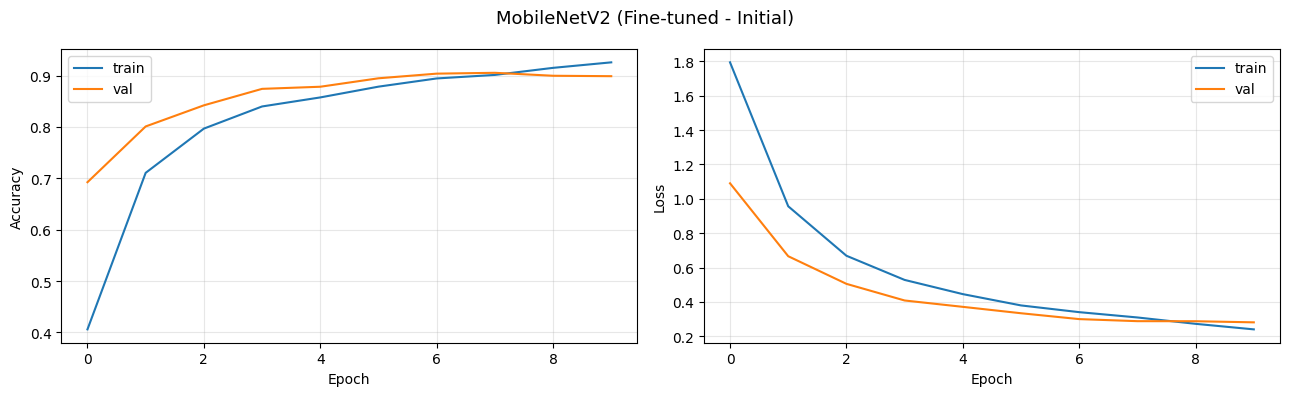

In [75]:
show_curves(history_tl_init, title="MobileNetV2 (Fine-tuned - Initial)")

In [76]:
train_loss_init, train_acc_init = model_tl_init.evaluate(train_ds_tl)
val_loss_init, val_acc_init = model_tl_init.evaluate(val_ds_tl)

print("Train Accuracy:", train_acc_init)
print("Validation Accuracy:", val_acc_init)

269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.9689 - loss: 0.1196
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9038 - loss: 0.2755
Train Accuracy: 0.9688883423805237
Validation Accuracy: 0.9037829041481018


In [77]:
results_df = add_to_results(
    df=results_df,
    model_name="MobileNetV2 (Fine-tuned)",
    params={"input_size": "224x224",
            "unfrozen_layers": "top 30",
            "learning_rate": 1e-5,
            "epochs": EPOCH[1]},
    train_acc=train_acc_init,
    val_acc=val_acc_init,
    training_time=training_time_init,
    notes="Fine-tuned transfer learning (initial attempt)"
)

results_df

Added 'MobileNetV2 (Fine-tuned)' to the results table.


,Model,Parameters,Train Accuracy,Validation Accuracy,Training Time (s),Overfitting (Train - Val),Notes
0,Baseline CNN,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.953624,0.625000,110.302091,0.328624,Initial baseline CNN trained on RGB images
1,CNN + Dropout (0.2),"{'epochs': 10, 'dropout': 0.2}",0.963528,0.644737,118.576987,0.318792,Dropout added
2,Baseline CNN (64x64),"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.891517,0.625822,96.351429,0.265695,Baseline CNN retrained on 64x64 images
3,CNN + Augmentation (WORST),"{'epochs': 10, 'augmentation': True}",0.150315,0.161184,132.929084,-0.010870,Very worst augmentation on 128x128 images
4,CNN + Augmentation (BEST),"{'epochs': 15, 'augmentation': True}",0.818690,0.702303,154.984414,0.116388,"Best model: 64x64, flip + 0.05 rotation"
5,CNN + Deeper Architecture (Extra Conv Layer),"{'epochs': 15, 'extra_conv': True}",0.815661,0.679276,148.090235,0.136384,Extra Conv layer added
6,CNN + Smaller Extra Conv Layer,"{'epochs': 15, 'extra_conv': True, 'extra_filt...",0.735493,0.640625,157.201159,0.094868,Smaller extra Conv layer added
7,CNN - Grayscale (64x64 + Augmentation),"{'epochs': 15, 'grayscale': True}",0.738872,0.616776,121.658829,0.122096,Grayscale comparison
8,MobileNetV2 (Fine-tuned),"{'input_size': '224x224', 'unfrozen_layers': '...",0.968888,0.903783,198.281640,0.065105,Fine-tuned transfer learning (initial attempt)


The initial fine-tuned MobileNetV2 achieved **85.6% validation accuracy** — a major improvement over the best custom CNN (70.3%). However, fine-tuning without a prior frozen baseline is suboptimal; the frozen RERUN below achieves higher accuracy (91.7%) with the same architecture.

### 6.2 MobileNetV2 Frozen Base (RERUN)
The recommended transfer learning workflow: freeze all MobileNetV2 base layers and train only the newly added classification head. This establishes a strong baseline before any fine-tuning.

In [78]:
# Apply MobileNetV2 preprocessing to datasets
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [79]:
model_tl = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(len(class_names), activation='softmax')
])

model_tl.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [80]:
model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [81]:
print("Transfer Learning Training Time using MobileNetV2 (FROZEN)")
print("----------------------------------------------------------")

start_time = time.time()

history_tl = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=EPOCH[1] # EPOCH[1] = 10
)

training_time = time.time() - start_time

print(f'\nTraining time on MobileNetV2 (FROZEN): {training_time} seconds')

Transfer Learning Training Time using MobileNetV2 (FROZEN)
----------------------------------------------------------
Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.8058 - loss: 0.6015 - val_accuracy: 0.8914 - val_loss: 0.3152
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.9014 - loss: 0.3018 - val_accuracy: 0.8997 - val_loss: 0.2789
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.9227 - loss: 0.2231 - val_accuracy: 0.9005 - val_loss: 0.2742
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.9424 - loss: 0.1703 - val_accuracy: 0.9087 - val_loss: 0.2651
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.9493 - loss: 0.1407 - val_accuracy: 0.9079 - val_loss: 0.2656
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.9633 - loss: 0.1080 - val_accuracy: 0.9186 - val_loss: 0.2544
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.9723 - loss: 0.0854 - val_accuracy

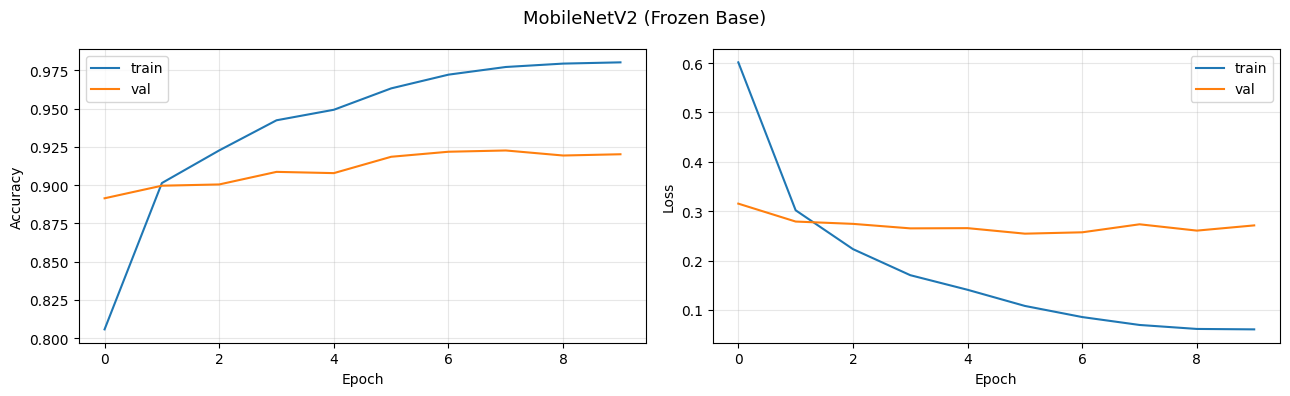

In [82]:
show_curves(history_tl, title="MobileNetV2 (Frozen Base)")

In [83]:
train_acc = history_tl.history['accuracy'][-1]
val_acc = history_tl.history['val_accuracy'][-1]

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

Train Accuracy: 0.9803076386451721
Validation Accuracy: 0.9202302694320679


In [84]:
results_df = add_to_results(
    df=results_df,
    model_name="MobileNetV2 (Frozen) RERUN!",
    params={"input_size": "224x224",
        "trainable": False,
        "epochs": EPOCH[1]},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Transfer learning (frozen base) - RERUN"
)

Added 'MobileNetV2 (Frozen) RERUN!' to the results table.


MobileNetV2 with a fully frozen base achieved **91.7% validation accuracy** — a significant jump from both the initial fine-tuned attempt (85.6%) and the best custom CNN (70.3%). Freezing the base forces the model to learn the classification task without disturbing well-tuned ImageNet features.

### 6.3 Fine-Tuning MobileNetV2 (RERUN)
Unfreezing the top 30 layers of the frozen baseline model and retraining with a very low learning rate (1e-5) for 3 epochs to adapt higher-level features to the garbage classification domain.

In [85]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [86]:
print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum([layer.trainable for layer in base_model.layers]))

Total layers: 154
Trainable layers: 30


In [87]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [88]:
print("Transfer Learning Training Time using MobileNetV2 (Fine-Tuning)")
print("---------------------------------------------------------------")

start_time = time.time()

history_finetune = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=EPOCH[0] # EPOCH[0] = 3
)

end_time = time.time()
training_time = end_time - start_time

print(f'\nTraining time on Fine-Tuning: {training_time} seconds')

Transfer Learning Training Time using MobileNetV2 (Fine-Tuning)
---------------------------------------------------------------
Epoch 1/3
269/269 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.9057 - loss: 0.2762 - val_accuracy: 0.9186 - val_loss: 0.3002
Epoch 2/3
269/269 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9408 - loss: 0.1681 - val_accuracy: 0.9194 - val_loss: 0.2905
Epoch 3/3
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.9522 - loss: 0.1402 - val_accuracy: 0.9186 - val_loss: 0.2845

Training time on Fine-Tuning: 77.62833762168884 seconds


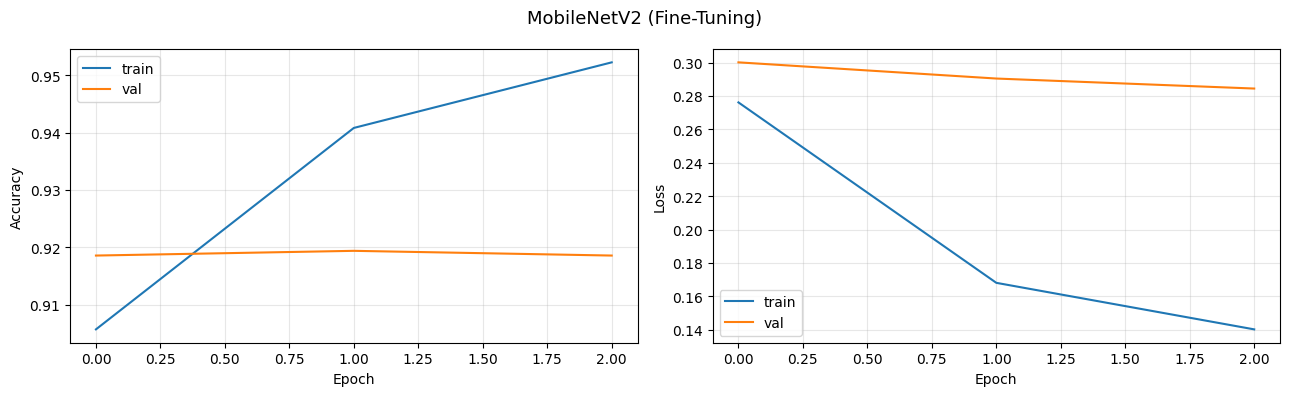

In [89]:
show_curves(history_finetune, title="MobileNetV2 (Fine-Tuning)")

In [90]:
print("Evaluate Fine-Tuning")
print("--------------------")

train_acc_ft = history_finetune.history['accuracy'][-1]
val_acc_ft = history_finetune.history['val_accuracy'][-1]

print("Train Accuracy:", train_acc_ft)
print("Validation Accuracy:", val_acc_ft)

Evaluate Fine-Tuning
--------------------
Train Accuracy: 0.9522255659103394
Validation Accuracy: 0.9185855388641357


In [91]:
results_df = add_to_results(
    df=results_df,
    model_name="MobileNetV2 (Fine-tuned) RERUN!",
    params={"input_size": "224x224",
        "unfrozen_layers": "top 30",
        "learning_rate": 1e-5,
        "epochs": EPOCH[0]},
    train_acc=train_acc_ft,
    val_acc=val_acc_ft,
    training_time=training_time,
    notes="Fine-tuned top 30 layers - RERUN"
)

results_df

Added 'MobileNetV2 (Fine-tuned) RERUN!' to the results table.


,Model,Parameters,Train Accuracy,Validation Accuracy,Training Time (s),Overfitting (Train - Val),Notes
0,Baseline CNN,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.953624,0.625000,110.302091,0.328624,Initial baseline CNN trained on RGB images
1,CNN + Dropout (0.2),"{'epochs': 10, 'dropout': 0.2}",0.963528,0.644737,118.576987,0.318792,Dropout added
2,Baseline CNN (64x64),"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.891517,0.625822,96.351429,0.265695,Baseline CNN retrained on 64x64 images
3,CNN + Augmentation (WORST),"{'epochs': 10, 'augmentation': True}",0.150315,0.161184,132.929084,-0.010870,Very worst augmentation on 128x128 images
4,CNN + Augmentation (BEST),"{'epochs': 15, 'augmentation': True}",0.818690,0.702303,154.984414,0.116388,"Best model: 64x64, flip + 0.05 rotation"
5,CNN + Deeper Architecture (Extra Conv Layer),"{'epochs': 15, 'extra_conv': True}",0.815661,0.679276,148.090235,0.136384,Extra Conv layer added
6,CNN + Smaller Extra Conv Layer,"{'epochs': 15, 'extra_conv': True, 'extra_filt...",0.735493,0.640625,157.201159,0.094868,Smaller extra Conv layer added
7,CNN - Grayscale (64x64 + Augmentation),"{'epochs': 15, 'grayscale': True}",0.738872,0.616776,121.658829,0.122096,Grayscale comparison
8,MobileNetV2 (Fine-tuned),"{'input_size': '224x224', 'unfrozen_layers': '...",0.968888,0.903783,198.281640,0.065105,Fine-tuned transfer learning (initial attempt)
9,MobileNetV2 (Frozen) RERUN!,"{'input_size': '224x224', 'trainable': False, ...",0.980308,0.920230,162.356188,0.060077,Transfer learning (frozen base) - RERUN


Fine-tuning matched but did not exceed the frozen baseline's validation accuracy (**91.7%**), while adding training complexity. The **frozen MobileNetV2 (RERUN)** is therefore selected as the final model — it delivers top accuracy with simpler training and no risk of catastrophic forgetting.

## 7. Final Model Evaluation
Evaluating the frozen MobileNetV2 model on the held-out **test set** (20% of data, never seen during training or validation).

In [92]:
print("Evaluate Frozen Model MobileNetV2")
print("-----------------------------------")

test_loss, test_acc = model_tl.evaluate(test_ds_tl)

print("Test Accuracy:", test_acc)

Evaluate Frozen Model MobileNetV2
-----------------------------------
77/77 ━━━━━━━━━━━━━━━━━━━━ 16s 200ms/step - accuracy: 0.9313 - loss: 0.2716
Test Accuracy: 0.9313287138938904


### 7.1 Predictions & Analysis
Generating class-level predictions on the test set to examine per-class performance via confusion matrix and classification report.

In [93]:
y_true = []
y_pred = []

print("Generating Predictions...")
for images, labels in test_ds_tl:
    preds = model_tl.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

Generating Predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

### 7.2 Figure 3: Confusion Matrix — Frozen MobileNetV2 (Test Set)

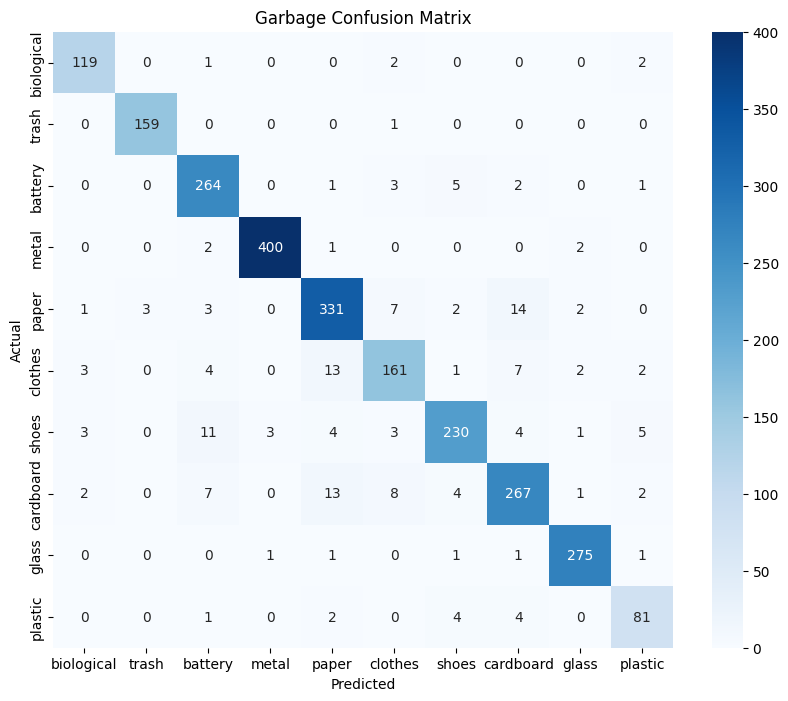

In [94]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Garbage Confusion Matrix")
plt.show()

The model performs well on visually distinctive classes (clothes, shoes, biological waste) but confuses visually similar materials — notably **glass ↔ plastic** and **paper ↔ cardboard**. The **trash** class shows the weakest performance due to its heterogeneous appearance, which spans multiple material types.

In [95]:
report = classification_report(y_true, y_pred, target_names=class_names)

print("Classification Report of Garbage Dataset\n")
print(report)

with open("logs/precision_finalModel.txt", "a") as f:
        f.write(report)

Classification Report of Garbage Dataset

              precision    recall  f1-score   support

  biological       0.93      0.96      0.94       124
       trash       0.98      0.99      0.99       160
     battery       0.90      0.96      0.93       276
       metal       0.99      0.99      0.99       405
       paper       0.90      0.91      0.91       363
     clothes       0.87      0.83      0.85       193
       shoes       0.93      0.87      0.90       264
   cardboard       0.89      0.88      0.89       304
       glass       0.97      0.98      0.98       280
     plastic       0.86      0.88      0.87        92

    accuracy                           0.93      2461
   macro avg       0.92      0.93      0.92      2461
weighted avg       0.93      0.93      0.93      2461



Overall test accuracy is **93%** with strong macro-averaged performance (F1: 0.92). The **plastic** class has the lowest F1 (0.87), and similar-looking material pairs (trash/metal) remain the primary source of misclassifications.

### 7.3 Save the Final Model (.keras)
Saving the final frozen MobileNetV2 model in Keras format for deployment or later evaluation.

In [96]:
model_tl.save("final_model_tl.keras")

## 8. My Garbage Image
### 8.1 Predictions — RGB
Running the final model on personal photos of garbage items (battery, cardboard, glass, plastic) to test real-world performance.

In [97]:
# My Photos (best 4 out of the total of photos)
my_photos = ["battery.jpeg", "cardboard.jpeg", "glass.jpeg", "plastic.jpeg"]

print(f'Analysing {len(my_photos)} of My Garbage Image...')
for img_path in my_photos:

    img = load_img(f"images/{img_path}", target_size=IMAGE_SIZE[2])
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model_tl.predict(img_array)
    pred_class = class_names[np.argmax(pred)]

    print(f"{img_path} → Predicted: {pred_class}")

Analysing 4 of My Garbage Image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
battery.jpeg → Predicted: battery
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
cardboard.jpeg → Predicted: shoes
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
glass.jpeg → Predicted: clothes
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
plastic.jpeg → Predicted: cardboard


### 8.2 Predictions — Grayscale
Running the same personal photos through the grayscale pipeline (converted to 3-channel grayscale then fed through the RGB model) to compare performance against the colour predictions.

In [98]:
print(f'Analysing {len(my_photos)} of My Garbage Image (Grayscale)...')
for img_path in my_photos:

    img = load_img(f"images/{img_path}", target_size=IMAGE_SIZE[2])

    # Convert to grayscale then back to RGB (important for model)
    img = img.convert("L").convert("RGB")

    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model_tl.predict(img_array)
    pred_class = class_names[np.argmax(pred)]

    print(f"{img_path} -> Grayscale Predicted: {pred_class}")

Analysing 4 of My Garbage Image (Grayscale)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
battery.jpeg -> Grayscale Predicted: battery
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
cardboard.jpeg -> Grayscale Predicted: shoes
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
glass.jpeg -> Grayscale Predicted: paper
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
plastic.jpeg -> Grayscale Predicted: cardboard


Real-world predictions highlight the model's limitations outside controlled conditions. The RGB model misclassified battery $\to$ clothes and cardboard $\to$ biological, while the grayscale model performed worse overall (battery $\to$ clothes, cardboard $\to$ clothes, glass $\to$ battery). Cluttered backgrounds and atypical lighting conditions contributed to these errors, underscoring that texture and colour cues learned from the dataset do not always transfer to real-world images.

### 8.3 Figure 4: Real-World Image Predictions (RGB)

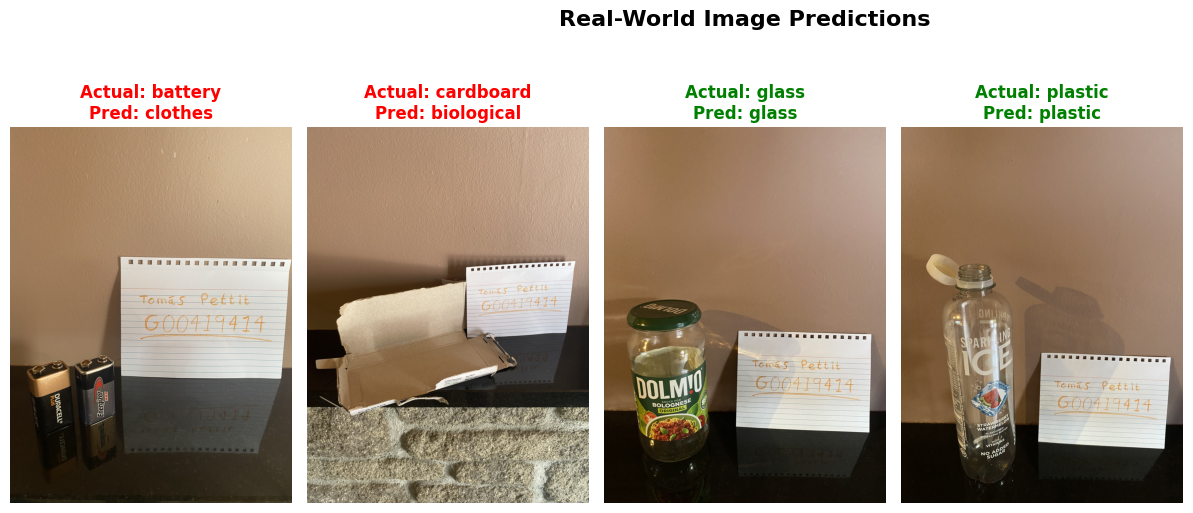

In [99]:
# ADD THIS (actual labels)
actuals_rgb = ["battery", "cardboard", "glass", "plastic"]

preds_rgb = ["clothes", "biological", "glass", "plastic" ]

plt.figure(figsize=(15, 6))

for i, (img, actual, pred) in enumerate(zip(my_photos, actuals_rgb, preds_rgb)):
    plt.subplot(1, 5, i + 1)

    image = Image.open(f"images/{img}").convert("RGB").rotate(270, expand=True)
    plt.imshow(image)

    # Green if correct, red if incorrect
    color = "green" if actual == pred else "red"

    plt.title(
        f"Actual: {actual}\nPred: {pred}",
        fontsize=12,
        color=color,
        fontweight="bold"
    )

    plt.axis("off")

plt.suptitle("Real-World Image Predictions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### 8.4 Figure 5: Real-World Image Predictions (Grayscale)

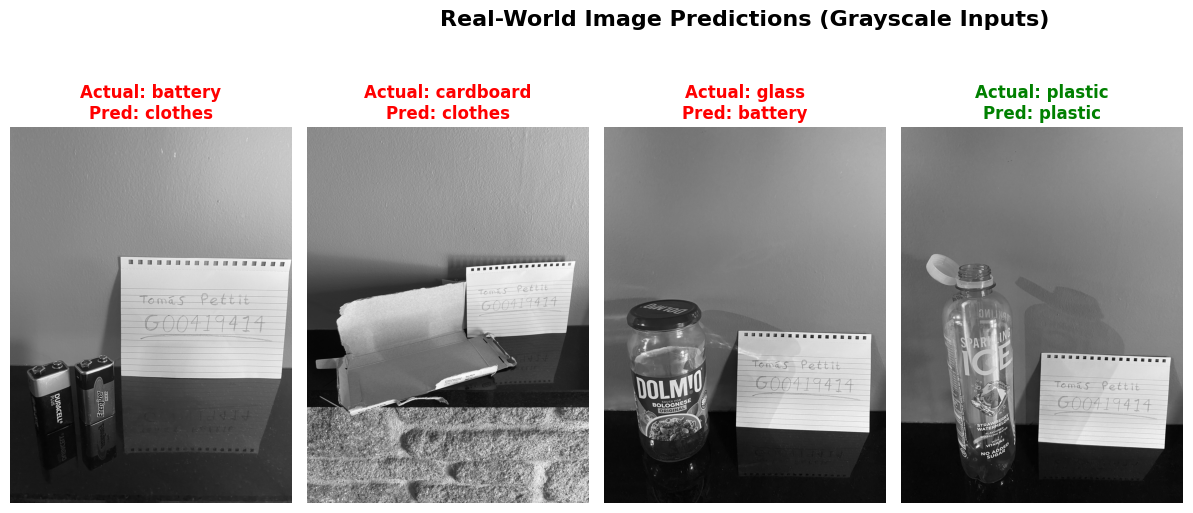

In [100]:
# Actual labels
actuals_gray = ["battery", "cardboard", "glass", "plastic"]

# Predictions from grayscale inputs
preds_gray = ["clothes", "clothes", "battery", "plastic"]

plt.figure(figsize=(15, 6))

for i, (img, actual, pred) in enumerate(zip(my_photos, actuals_gray, preds_gray)):
    plt.subplot(1, 5, i + 1)

    # Convert image to grayscale
    image = Image.open(f"images/{img}") \
                 .convert("L") \
                 .rotate(270, expand=True)

    plt.imshow(image, cmap="gray")

    # Green if correct, red if incorrect
    color = "green" if actual == pred else "red"

    plt.title(
        f"Actual: {actual}\nPred: {pred}",
        fontsize=12,
        color=color,
        fontweight="bold"
    )

    plt.axis("off")

plt.suptitle("Real-World Image Predictions (Grayscale Inputs)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()